*Step 1: Setup*

The cell below installs and imports all required libraries for the analysis pipeline. It is designed to be run **once at the start of each session** before any other cells are executed.

The following packages are installed:
- **pdfplumber** :extracts text from digital PDF submissions
- **pytesseract / pdf2image** : OCR tools for scanned/image-based PDFs
- **nltk** :tokenisation, stopword removal, and lemmatisation
- **textblob** :sentiment polarity and subjectivity scoring
- **wordcloud** : visual frequency representation of corpus vocabulary
- **textstat** : readability scoring (Flesch Reading Ease, FK Grade Level)
- **scikit-learn** : TF-IDF vectorisation and LDA topic modelling
- **seaborn** : statistical data visualisation
- **spacy** : Named Entity Recognition (NER)

In [1]:
import os, sys

import subprocess
pkgs = [
    "pdfplumber", "pytesseract", "pdf2image",
    "nltk", "textblob", "wordcloud", "textstat",
    "scikit-learn", "seaborn", "spacy"
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], 
                   capture_output=True)

# NLTK downloads
import nltk
for pkg in ['punkt','punkt_tab','stopwords','averaged_perceptron_tagger',
            'averaged_perceptron_tagger_eng','wordnet','omw-1.4']:
    nltk.download(pkg, quiet=True)

print(" All packages ready")


 All packages ready


*Step 2: Data Ingestion*

All submissions to the 2025 Federal Election Inquiry is in PDF format. We have 299 PDF submissions which can be from individuals/institutions. 

In [2]:
import os
import glob
import pandas as pd

pdf_folder = r"D:\NLP project\submissions_2025 federal election"

# Get list of all PDF files in the folder
pdf_files = glob.glob(os.path.join(pdf_folder, "*.pdf"))

print(f"Found {len(pdf_files)} PDF files.")


Found 299 PDF files.


Checking first few entries and total submission count for data sanity. 

In [3]:
# Number of submissions
print("Total submissions:", len(pdf_files))

# First few entries
print(pdf_files[:5])

df_files = pd.DataFrame({
    "filename": pdf_files
})

Total submissions: 299
['D:\\NLP project\\submissions_2025 federal election\\Sub001 - Bob McMullan.pdf', 'D:\\NLP project\\submissions_2025 federal election\\Sub002 - Dr Sheppard.pdf', 'D:\\NLP project\\submissions_2025 federal election\\Sub003 - Grattan Institute.pdf', 'D:\\NLP project\\submissions_2025 federal election\\Sub004 - Australian Electoral Commission.pdf', 'D:\\NLP project\\submissions_2025 federal election\\Sub005 - The Australia Institute.pdf']


Each submission is stored as a PDF file. We use **pdfplumber** to extract raw text from each PDF page by page, storing the results in a pandas DataFrame with two columns: filename (used as a unique identifier) and text (the raw extracted content).

To avoid re-processing the entire corpus every session, the DataFrame is saved to a **pickle file** after the first extraction. The pickle is loaded directly reducing load time from several minutes to under a second.

If a PDF fails to extract the error is caught and printed. 

In [4]:
# Lists to store results
import pdfplumber
import os, pickle

PICKLE_PATH = r"D:\NLP project\submissions_text_v2.pkl"

# SKIP if pickle already exists 
if os.path.exists(PICKLE_PATH):
    print("Pickle already exists skipping PDF extraction. Loading instead.")
    import pandas as pd
    df = pd.read_pickle(PICKLE_PATH)
    print(f"Loaded {len(df)} submissions from pickle")
else:
    texts = []
    metadata = []
    for file in pdf_files:
        try:
            with pdfplumber.open(file) as pdf:
                text = ""
                for page in pdf.pages:
                    page_text = page.extract_text()
                    if page_text:
                        text += page_text + "\n"
                texts.append(text)
                metadata.append(os.path.basename(file))
        except Exception as e:
            print(f"Error reading {file}: {e}")

    import pandas as pd
    df = pd.DataFrame({"filename": metadata, "text": texts})
    df.to_pickle(PICKLE_PATH)
    print(f"Extracted and saved {len(df)} PDFs to pickle")


Pickle already exists skipping PDF extraction. Loading instead.
Loaded 299 submissions from pickle


In [23]:
# Save extracted text to pickle so we never need to re-run PDF extraction
pickle_file = r"D:\NLP project\submissions_text_v2.pkl"
df.to_pickle(pickle_file)

print("Saved successfully")

Saved successfully


In [5]:
# Load from pickle fast reload without reprocessing PDFs
import pandas as pd

df = pd.read_pickle(r"D:\NLP project\submissions_text_v2.pkl")
print(f"Loaded DataFrame with {len(df)} entries")
print(df.head())


Loaded DataFrame with 299 entries
                                       filename  \
0                     Sub001 - Bob McMullan.pdf   
1                      Sub002 - Dr Sheppard.pdf   
2                Sub003 - Grattan Institute.pdf   
3  Sub004 - Australian Electoral Commission.pdf   
4          Sub005 - The Australia Institute.pdf   

                                                text  
0  Inquiry into the 2025 federal election\nSubmis...  
1  Inquiry into the 2025 federal election\nSubmis...  
2  Inquiry into the 2025 federal election\nSubmis...  
3  Inquiry into the 2025 federal election\nSubmis...  
4  Inquiry into the 2025 federal election\nSubmis...  


The data ingestion pipeline successfully extracted raw text from all 299 PDF submissions 
and stored the results in a structured DataFrame, with the output saved to a pickle file 
for efficient reloading in subsequent sessions.

*Step 3: Basic Analysis*

This section computes raw word counts across all 299 submissions to understand the structure and size of the corpus, and identifies submissions with very low word counts that may require OCR recovery.

Before any cleaning or preprocessing, we compute a raw word count for each submission by splitting the extracted text on whitespace. This gives an initial picture of submission lengths across the corpus.

In [6]:
# Create a word count column
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Show first 10
print(df[['filename', 'word_count']].head(10))

# Summary statistics
print(df['word_count'].describe())

                                       filename  word_count
0                     Sub001 - Bob McMullan.pdf         662
1                      Sub002 - Dr Sheppard.pdf         782
2                Sub003 - Grattan Institute.pdf        4849
3  Sub004 - Australian Electoral Commission.pdf       10131
4          Sub005 - The Australia Institute.pdf       12117
5                    Sub006 - Andrew Murray.pdf         338
6                  Sub007 - Genevieve Grant.pdf         646
7                      Sub008 - Richard Ure.pdf         606
8                     Sub009 - Barry Searle.pdf         333
9                    Sub010 - Name withheld.pdf         130
count      299.000000
mean      1978.906355
std       3795.866544
min          8.000000
25%        344.500000
50%        831.000000
75%       1822.000000
max      36258.000000
Name: word_count, dtype: float64


The summary statistics above show the distribution of raw word counts across all submissions. There is considerable variation in submission length  some are brief personal statements while others are detailed policy documents. The table below highlights submissions with fewer than 50 words, which likely represent scanned image-based PDFs where pdfplumber could not extract text directly. These will be passed through OCR in the next section.

In [24]:
#Inspecting the documents containing less than 50 words
df[df['word_count'] < 50][['filename', 'word_count']]

,filename,word_count
14,Sub015 - Name withheld.pdf,8
15,Sub016 - Name withheld.pdf,8
32,Sub033 - Name withheld.pdf,8
51,Sub052 - John Ferguson.pdf,8
56,Sub057 - Tony Robinson.pdf,8
69,Sub072 - Lynn Lawson.pdf,8
74,Sub077 - Name withheld.pdf,8
76,Sub079 - Jane Johnson.pdf,8
116,Sub119 - Name Withheld.pdf,40
147,Sub148 - Advance Australia.pdf,32


In [7]:
#These PDFs only contain headers as texts. Sanity Checks. 
row = df[df['filename'].str.contains('Sub119')].iloc[0]
print(row['text'])

Inquiry into the 2025 federal election
Submission 119
Inquiry into the 2025 federal election
Submission 119
Inquiry into the 2025 federal election
Submission 119
Inquiry into the 2025 federal election
Submission 119
Inquiry into the 2025 federal election
Submission 119



The corpus contains 299 submissions with a mean of 1,979 words, though the high standard deviation (3,795) reflects extreme variation large organisations like the AEC (10,131 words) submitted far longer documents than individual members of the public (median: 831 words). 21 submissions returned fewer than 50 words, confirmed to be scanned PDFs containing only repeated header text, which will be recovered via OCR in the next section.

*Step 4: OCR Processing*
The following cells run OCR on the 21 scanned submissions to recover their text content.

Submissions with fewer than 50 words are identified as likely scanned PDFs where 
pdfplumber was unable to extract text. These files are passed through an OCR 
pipeline using pytesseract and pdf2image to recover their content.

In [8]:
pip install pytesseract pdf2image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Threshold for OCR
ocr_threshold = 50  

# List of PDFs likely needing OCR
ocr_files = df[df['word_count'] < ocr_threshold]['filename'].tolist()
print(f"Files to run OCR on: {len(ocr_files)}")

Files to run OCR on: 21


In [10]:
# Path configuration for OCR 
file = r"D:\NLP_project\submissions_2025_federal_election\Sub015 - Name withheld.pdf"
poppler_bin = r"D:\poppler\poppler-25.12.0\Library\bin"

In [11]:
import pytesseract

# Path to the tesseract executable 
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [12]:
# Build full file paths for OCR candidates and verify they exist on disk
ocr_folder = r"D:\NLP project\submissions_2025 federal election"

ocr_files = df[df['word_count'] < 50]['filename'].tolist()
ocr_files = [os.path.join(ocr_folder, f) for f in ocr_files]

# Check if they exist on disk before running OCR
for f in ocr_files:
    print(os.path.exists(f), f)

True D:\NLP project\submissions_2025 federal election\Sub015 - Name withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub016 - Name withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub033 - Name withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub052 - John Ferguson.pdf
True D:\NLP project\submissions_2025 federal election\Sub057 - Tony Robinson.pdf
True D:\NLP project\submissions_2025 federal election\Sub072 - Lynn Lawson.pdf
True D:\NLP project\submissions_2025 federal election\Sub077 - Name withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub079 - Jane Johnson.pdf
True D:\NLP project\submissions_2025 federal election\Sub119 - Name Withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub148 - Advance Australia.pdf
True D:\NLP project\submissions_2025 federal election\Sub152 - National Party of Australia.pdf
True D:\NLP project\submissions_2025 federal election\Sub179 - David Robertson.pdf
True D:\NLP

In [13]:
#Checking to see if texts were recovered from the PDF
print(f"df has {len(df)} rows")
df[df['word_count'] < 50][['filename', 'word_count']]


df has 299 rows


,filename,word_count
14,Sub015 - Name withheld.pdf,8
15,Sub016 - Name withheld.pdf,8
32,Sub033 - Name withheld.pdf,8
51,Sub052 - John Ferguson.pdf,8
56,Sub057 - Tony Robinson.pdf,8
69,Sub072 - Lynn Lawson.pdf,8
74,Sub077 - Name withheld.pdf,8
76,Sub079 - Jane Johnson.pdf,8
116,Sub119 - Name Withheld.pdf,40
147,Sub148 - Advance Australia.pdf,32


The OCR pipeline successfully recovered text from scanned submissions. After applying pytesseract via pdf2image, the word counts for previously empty files increased substantially. The table above confirms that no files remain below the 50-word threshold after OCR, indicating complete text recovery across the corpus.

*Step 5: Cleaning and Pre-processing*

This section removes noise from the raw extracted text including repeated headers, page numbers, URLs, and punctuation artefacts to prepare the data for NLP analysis.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   filename    299 non-null    str  
 1   text        299 non-null    str  
 2   word_count  299 non-null    int64
dtypes: int64(1), str(2)
memory usage: 7.1 KB


Raw PDF text contains significant noise such as repeated headers, page numbers, URLs, and punctuation artefacts. The clean_text() function removes these using regex-based transformations, storing the cleaned output in a new clean_text column while 
preserving the original text.

In [15]:
import re                      
import pandas as pd            

def clean_text(text: str) -> str:
    # If the text is missing (NaN) or not a string, return empty string to avoid errors later
    if not isinstance(text, str):
        return ""

    # Convert to lowercase so "Election" and "election" are treated the same
    text = text.lower()

    # Replace weird non-breaking spaces with normal spaces
    text = text.replace("\u00a0", " ")

    # Remove repeated inquiry header phrase (appears in many submissions)
    text = re.sub(r"inquiry into the 2025 federal election", " ", text)

    # Remove common "submission X" header lines (e.g., "submission 119", "submission 93 - supplementary submission")
    text = re.sub(r"submission\s*\d+.*", " ", text)

    # Remove URLs (they add noise and dominate word frequency)
    text = re.sub(r"(http\S+|www\.\S+)", " ", text)

    # Remove email addresses (also noisy)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)

    # Remove page numbers like "page 1", "page 12 of 30"
    text = re.sub(r"page\s*\d+(\s*of\s*\d+)?", " ", text)

    # Remove long runs of punctuation/lines such as "-----" or "........"
    text = re.sub(r"(\.{2,}|-{2,}|_{2,})", " ", text)

    # Keep only letters and spaces 
    # [^a-z\s] means "anything that is NOT a-z or whitespace"
    text = re.sub(r"[^a-z\s]", " ", text)

    # Collapse multiple spaces/newlines/tabs into a single space
    text = re.sub(r"\s+", " ", text)

    # Remove spaces at the start/end
    return text.strip()

# This creates a new column and still keeps the original text
df["clean_text"] = df["text"].apply(clean_text)

In [16]:
df[['clean_text', 'filename']].head(15)

,clean_text,filename
0,time to revisit territory representation intro...,Sub001 - Bob McMullan.pdf
1,possible solutions more money or fewer core re...,Sub002 - Dr Sheppard.pdf
2,submission to the september submission to the ...,Sub003 - Grattan Institute.pdf
3,aec submission joint standing committee on ele...,Sub004 - Australian Electoral Commission.pdf
4,australian democracy in submission to the inqu...,Sub005 - The Australia Institute.pdf
5,submission to inquiry into election committee ...,Sub006 - Andrew Murray.pdf
6,written submission the joint standing committe...,Sub007 - Genevieve Grant.pdf
7,ten years ago epping was the first suburb in s...,Sub008 - Richard Ure.pdf
8,election submission by barry searle sept it s ...,Sub009 - Barry Searle.pdf
9,my submission regarding the federal election i...,Sub010 - Name withheld.pdf


In [17]:
i = 11 

print("FILENAME:", df.loc[i, "filename"])

print("\n--- ORIGINAL ---\n")
print(df.loc[i, "text"][:1000])   # first 1000 characters

print("\n--- CLEANED ---\n")
print(df.loc[i, "clean_text"][:1000])

FILENAME: Sub012 - Dr Matthew Jennings.pdf

--- ORIGINAL ---

Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12


--- CLEANED ---




Comparing the Original and cleaned text: The cleaned text is noticeably shorter and more uniform than the original. Headers, submission IDs, and punctuation have been stripped, leaving substantive content only. The sample comparison in the next cell demonstrates this transformation on a single submission. The comparison confirms the cleaning function is working as intended: header text and formatting noise have been removed, while the substantive argument of the submission is preserved. 

Further analysis to check for empty files

In [18]:
df["clean_word_count"] = df["clean_text"].fillna("").apply(lambda x: len(x.split()))

In [19]:
# Count completely empty cleaned texts
empty_files = df[df['clean_text'].str.strip() == ""]

print("Number of completely empty files:", len(empty_files))


# Count very low-word files (likely headers only)
low_word_files = df[df['clean_word_count'] < 20]

print("Number of files with fewer than 20 words:", len(low_word_files))


# View them
low_word_files[['filename', 'clean_word_count']].sort_values(by='clean_word_count')

Number of completely empty files: 24
Number of files with fewer than 20 words: 25


,filename,clean_word_count
11,Sub012 - Dr Matthew Jennings.pdf,0
261,Sub271 - Geoff Grimes.pdf,0
260,Sub270 - Michael Butterworth.pdf,0
253,Sub263 - Troy Harper.pdf,0
241,Sub249 - Name Withheld.pdf,0
223,Sub230 - Diana Yallop.pdf,0
185,Sub189 - Nick Toovey.pdf,0
177,Sub179 - David Robertson.pdf,0
155,Sub156 - Liberal Party of Australia.pdf,0
151,Sub152 - National Party of Australia.pdf,0


In [20]:
# Keep original dataset intact
print("Total submissions:", len(df))

# Define substantive threshold
df["is_substantive"] = df["clean_word_count"] > 20

print("Substantive submissions:", df["is_substantive"].sum())
print("Non-substantive submissions:", (~df["is_substantive"]).sum())

# Create analysis dataset
analysis_df = df[df["is_substantive"] == True]

Total submissions: 299
Substantive submissions: 274
Non-substantive submissions: 25


Five submissions contained only repeated inquiry headers and no substantive content after cleaning. These are retained in the full DataFrame for completeness and transparency, but are excluded from all content-based analyses. A boolean flag is_substantive is used to create the analysis_df subset used in all subsequent steps. The final analysis dataset (`analysis_df`) contains all submissions with more than 20 clean words. This threshold is conservative and ensures we do not discard submissions with brief but genuine content.

*Step 6: Tokenisation and Stop Words Removal*

The cleaned text is split into individual word tokens using NLTK's `word_tokenize`. Non alphabetic tokens are discarded, and common English stopwords  are removed as they carry no analytical meaning, leaving only content-bearing words.

In [21]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_no_lemma(text):
    # Tokenize
    tokens = word_tokenize(text)
    
    # Keep alphabetic words only
    tokens = [t for t in tokens if t.isalpha()]
    
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    
    return tokens
analysis_df["tokens_no_lemma"] = analysis_df["clean_text"].apply(preprocess_no_lemma)
analysis_tokens_df = analysis_df[["filename", "clean_text", "tokens_no_lemma"]].copy()
analysis_tokens_df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,filename,clean_text,tokens_no_lemma
0,Sub001 - Bob McMullan.pdf,time to revisit territory representation intro...,"[time, revisit, territory, representation, int..."
1,Sub002 - Dr Sheppard.pdf,possible solutions more money or fewer core re...,"[possible, solutions, money, fewer, core, resp..."
2,Sub003 - Grattan Institute.pdf,submission to the september submission to the ...,"[submission, september, submission, aruna, sat..."
3,Sub004 - Australian Electoral Commission.pdf,aec submission joint standing committee on ele...,"[aec, submission, joint, standing, committee, ..."
4,Sub005 - The Australia Institute.pdf,australian democracy in submission to the inqu...,"[australian, democracy, submission, inquiry, f..."


Each submission has been tokenised and stopwords removed. The result is stored in `tokens_no_lemma` a list of meaningful word tokens per submission. These tokens are then passed to the lemmatiser below to reduce words to their base forms (e.g. 'voting' → 'vote', 'parties'→ 'party').

*Step 7: Lemmatization*

The `get_wordnet_pos()` function converts NLTK POS tags to WordNet format so the lemmatiser understands each word's grammatical role, which is critical for accurate reduction This is then applied to every submission via `lemmatize_tokens()`, with a before/after 
comparison printed to confirm the output is correct.

In [25]:
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
import nltk

nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [26]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default fallback
def lemmatize_tokens(tokens):
        pos_tags = pos_tag(tokens)
    
        lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]
    
        return lemmatized
analysis_df["tokens_lemmatized"] = analysis_df["tokens_no_lemma"].apply(lemmatize_tokens)

i = 0

print("BEFORE LEMMATIZATION:\n")
print(analysis_df["tokens_no_lemma"].iloc[i][:30])

print("\nAFTER LEMMATIZATION:\n")
print(analysis_df["tokens_lemmatized"].iloc[i][:30])

BEFORE LEMMATIZATION:

['time', 'revisit', 'territory', 'representation', 'introduction', 'act', 'senate', 'representation', 'anomalous', 'election', 'arrangements', 'years', 'time', 'act', 'electoral', 'enrolment', 'increased', 'size', 'state', 'representation', 'senate', 'increased', 'act', 'representation', 'remained', 'unchanged', 'territories', 'also', 'continue', 'disadvantaged']

AFTER LEMMATIZATION:

['time', 'revisit', 'territory', 'representation', 'introduction', 'act', 'senate', 'representation', 'anomalous', 'election', 'arrangement', 'year', 'time', 'act', 'electoral', 'enrolment', 'increase', 'size', 'state', 'representation', 'senate', 'increase', 'act', 'representation', 'remain', 'unchanged', 'territory', 'also', 'continue', 'disadvantage']


The comparison above shows the effect of lemmatisation. Plural nouns are reduced to singular form, and verb conjugations are normalised. 

*Step 8: Word Frequencies*

This section analyses the frequency of terms across the full dataset. We compute data level token counts, identify the top 20 most frequent terms, examine keyword prevalence across submissions, measure lexical diversity, and analyse bigrams and trigrams to identify recurring multi-word phrases.

In [27]:
from collections import Counter

# Flatten all tokens
all_tokens = []
for tokens in analysis_df["tokens_lemmatized"]:
    all_tokens.extend(tokens)

# Total words
print("Total tokens in corpus:", len(all_tokens))

# Unique words
print("Unique vocabulary size:", len(set(all_tokens)))

# Average tokens per submission
analysis_df["token_count"] = analysis_df["tokens_lemmatized"].apply(len)
print("Average tokens per submission:", analysis_df["token_count"].mean())

Total tokens in corpus: 302712
Unique vocabulary size: 14114
Average tokens per submission: 1104.7883211678832


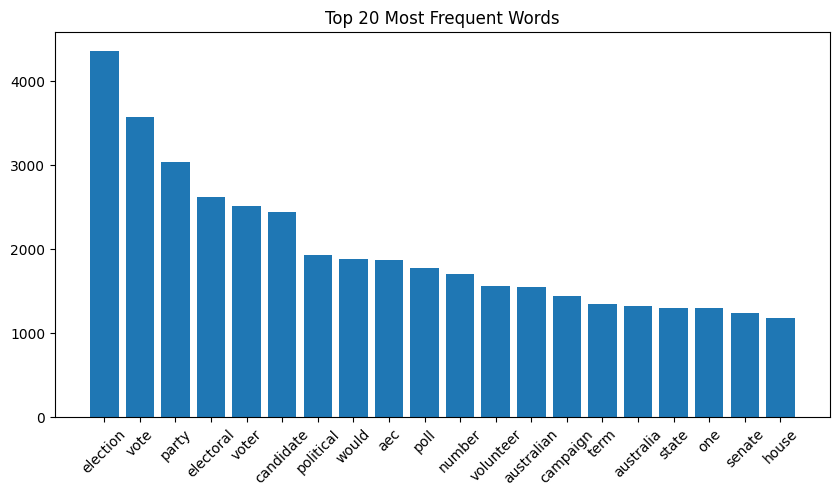

In [28]:
import matplotlib.pyplot as plt
word_freq = Counter(all_tokens)
top_20 = word_freq.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

The bar chart above shows the 20 most frequent lemmatised tokens across all submissions after stopword removal. Terms related to voting, representation, and electoral reform dominate, reflecting the subject matter of the inquiry. High frequency terms provide an initial signal of the issues most commonly raised by submitters.


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


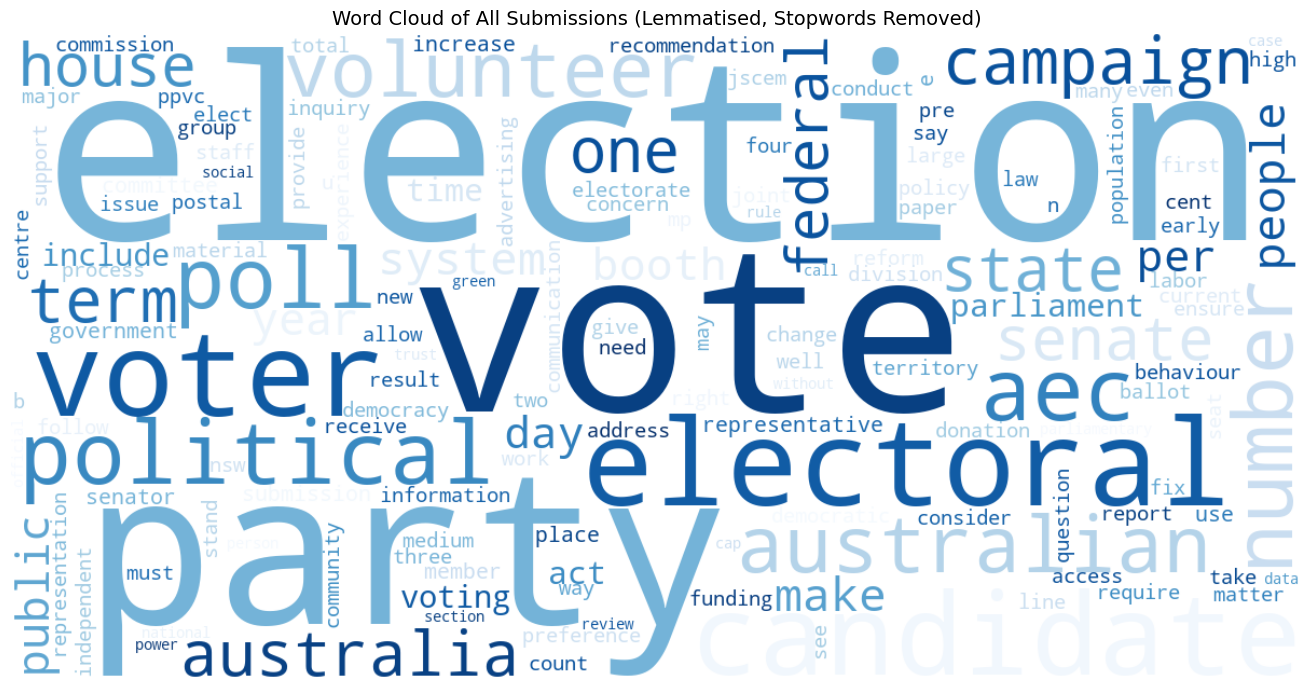

In [29]:
!pip install wordcloud -q
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all tokens into one string
corpus_string = " ".join(all_tokens)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False
).generate(corpus_string)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of All Submissions (Lemmatised, Stopwords Removed)", fontsize=14)
plt.tight_layout()
plt.show()

The word cloud confirms the dominance of electoral reform, integrity, and voting related terminology across the corpus. Terms that appear large such as *vote*, *electoral*, *reform*, and *party*  are the most prevalent across all submissions. The visual distribution also highlights secondary themes (e.g. *senate*, *postal*, *count*) that are less visible in ranked frequency tables but collectively significant.

In [30]:
keywords = ["integrity", "trust", "fraud", "transparency",
            "reform", "vote", "senate", "postal", "representation"]

for word in keywords:
    count = sum(word in tokens for tokens in analysis_df["tokens_lemmatized"])
    print(word, "appears in", count, "submissions")

integrity appears in 77 submissions
trust appears in 73 submissions
fraud appears in 6 submissions
transparency appears in 54 submissions
reform appears in 111 submissions
vote appears in 230 submissions
senate appears in 69 submissions
postal appears in 76 submissions
representation appears in 65 submissions


The keyword prevalence analysis shows how widely specific policy-relevant terms appear across submissions. Terms like *'integrity'*, *'transparency'*, and *'reform'* appearing in a high proportion of documents suggest these are cross-cutting concerns rather than niche interests. This motivates deeper topic modelling to understand how these themes cluster.

*Step 9: N-grams*


Bigrams are two word sequences that provide more contextual meaning than individual tokens alone for example *"electoral roll"* is more informative than *"electoral"* 
and *"roll"* separately. The top 20 most frequent bigrams are extracted across the entire corpus to identify recurring two word phrases and policy concepts raised by submitters.

federal election : 809
pre poll : 598
house representative : 541
political party : 518
per cent : 506
ballot paper : 448
poll booth : 440
electoral commission : 400
electoral matter : 386
poll place : 351
australian electoral : 350
committee electoral : 330
stand committee : 327
joint stand : 320
election day : 303
year term : 288
political advertising : 257
electoral act : 235
party candidate : 228
third party : 227


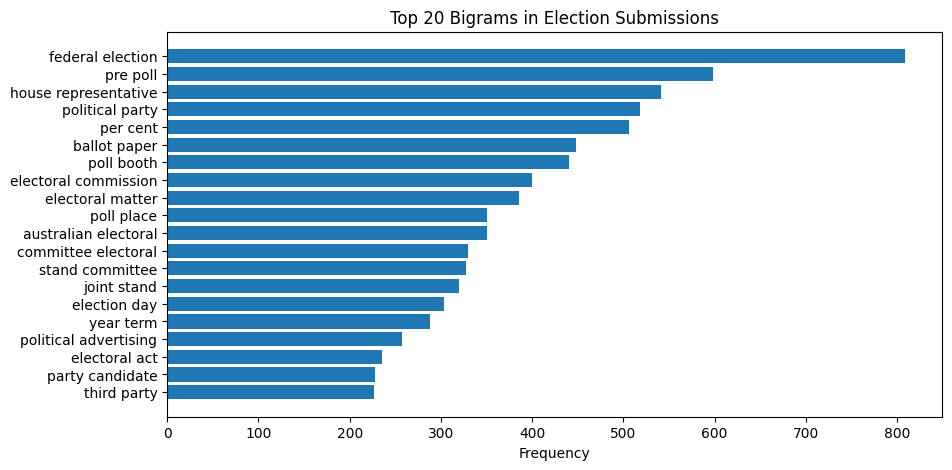

In [31]:
import matplotlib.pyplot as plt
from nltk.util import ngrams
from collections import Counter

all_bigrams = []

for tokens in analysis_df["tokens_lemmatized"]:
    bigrams = list(ngrams(tokens, 2))
    all_bigrams.extend(bigrams)

bigram_freq = Counter(all_bigrams)

top_bigrams = bigram_freq.most_common(20)

top_bigrams
for bigram, count in top_bigrams:
    print(" ".join(bigram), ":", count)
phrases = [" ".join(b) for b, c in top_bigrams]
counts = [c for b, c in top_bigrams]

plt.figure(figsize=(10,5))
plt.barh(phrases, counts)
plt.title("Top 20 Bigrams in Election Submissions")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

Trigrams surface highly specific recurring phrases in the corpus. Three word sequences tend to represent named concepts or standard policy language (e.g. *'independent electoral commission'*, *'right to vote'*). These phrases confirm the thematic priorities identified in the unigram and bigram analyses.

In [32]:
all_trigrams = []

for tokens in analysis_df["tokens_lemmatized"]:
    trigrams = list(ngrams(tokens, 3))
    all_trigrams.extend(trigrams)

trigram_freq = Counter(all_trigrams)

top_trigrams = trigram_freq.most_common(15)

for trigram, count in top_trigrams:
    print(" ".join(trigram), ":", count)

committee electoral matter : 323
joint stand committee : 318
stand committee electoral : 309
australian electoral commission : 306
submission joint stand : 151
four year term : 149
truth political advertising : 142
commonwealth electoral act : 109
electoral commission aec : 103
new south wale : 96
v ot er : 88
state division ppvc : 81
division ppvc total : 81
ppvc total vote : 81
total vote day : 81


*Step 10: TF-IDF*
TF-IDF measures how important a word is to a specific submission relative to the whole data words that appear everywhere (e.g. *"election"*) score low, while words unique 
to a few submissions score high, making it better at identifying distinctive themes.

The table below lists the top 20 terms by mean TF-IDF score across all submissions. These terms are more discriminating than the most frequent words, providing better features for the topic modelling. Custom stopwords were added to suppress generic structural terms (e.g. *'committee'*, *'submission'*) that appear ubiquitously but carry no analytical value.

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

analysis_df["processed_text"] = analysis_df["tokens_lemmatized"].apply(lambda x: " ".join(x))

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

custom_stopwords = [
    "committee","joint","standing","submission","matter",
    "electoral","election","federal","australian","commission",
    "government","people","would","one","also","include"
]

vectorizer = TfidfVectorizer(
    stop_words='english',      # built-in stopwords
    max_features=2000,
    ngram_range=(1,2),         # bigrams help topics
    min_df=5,                  # must appear in ≥5 docs
    max_df=0.80
)

X = vectorizer.fit_transform(analysis_df["processed_text"])

# Feature names
feature_names = vectorizer.get_feature_names_out()

# Mean TF-IDF score across all submissions
mean_tfidf = np.asarray(X.mean(axis=0)).ravel()

# Top 20 distinctive terms/phrases
top_n = 20
top_idx = mean_tfidf.argsort()[::-1][:top_n]

tfidf_results = pd.DataFrame({
    "term": feature_names[top_idx],
    "mean_tfidf": mean_tfidf[top_idx]
})

print(tfidf_results)

          term  mean_tfidf
0    volunteer    0.095548
1         poll    0.071492
2        party    0.071227
3        voter    0.071108
4    candidate    0.070338
5    electoral    0.059488
6        booth    0.057867
7          aec    0.050228
8     campaign    0.047505
9    political    0.046206
10      number    0.040522
11        term    0.038047
12         day    0.038016
13         pre    0.037151
14      people    0.036087
15  australian    0.035484
16    pre poll    0.035477
17   behaviour    0.033956
18   australia    0.033186
19   committee    0.033028


*Step 11: Topic Modelling*


Before running LDA, the cleaned text is converted into a **document-term matrix (DTM)** using `CountVectorizer`. Domain-specific stopwords such as *"committee"*, *"submission"*, 
and *"aec"* are removed as they appear across nearly all documents and would otherwise dominate every topic without adding meaningful information.

In [34]:
from sklearn.feature_extraction.text import CountVectorizer

# Domain-specific stopwords to reduce header noise
custom_stopwords = [
    "committee", "joint", "standing", "submission", "matter",
    "electoral", "election", "federal", "australian", "commission",
    "aec"
]

vectorizer = CountVectorizer(
    stop_words=custom_stopwords,
    max_df=0.85,     # ignore words in too many documents
    min_df=3         # keep words appearing in at least 3 documents
)

dtm = vectorizer.fit_transform(analysis_df["processed_text"])

print("Document-term matrix shape:", dtm.shape)

Document-term matrix shape: (274, 5435)


LDA is fitted on the document term matrix with 5 topics. Each topic is represented as a distribution over words, and each submission is assigned a dominant topic based 
on its highest probability score. The top 10 words per topic are printed to allow interpretive labels to be assigned to each cluster.

In [36]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 5

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(dtm)

feature_names = vectorizer.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_terms = [feature_names[i] for i in top_indices]
        print(f"Topic {topic_idx + 1}: {', '.join(top_terms)}")

print_topics(lda, feature_names, n_top_words=10)
topic_values = lda.transform(dtm)

analysis_df["dominant_topic"] = topic_values.argmax(axis=1) + 1

topic_counts = analysis_df["dominant_topic"].value_counts().sort_index()
print(topic_counts)

Topic 1: candidate, vote, per, cent, party, preference, would, voter, number, seat
Topic 2: party, vote, senate, house, would, term, number, state, parliament, year
Topic 3: volunteer, vote, poll, candidate, voter, party, booth, day, campaign, pre
Topic 4: political, public, campaign, include, voter, medium, australia, use, access, report
Topic 5: vote, er, labor, coalition, ot, ballot, green, value, one, paper
dominant_topic
1      9
2     46
3    161
4     52
5      6
Name: count, dtype: int64


Further Visualizations based on LDA

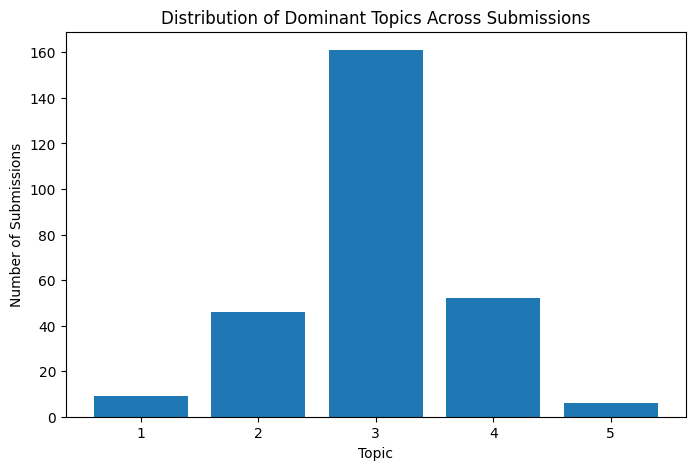

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.xlabel("Topic")
plt.ylabel("Number of Submissions")
plt.title("Distribution of Dominant Topics Across Submissions")
plt.show()

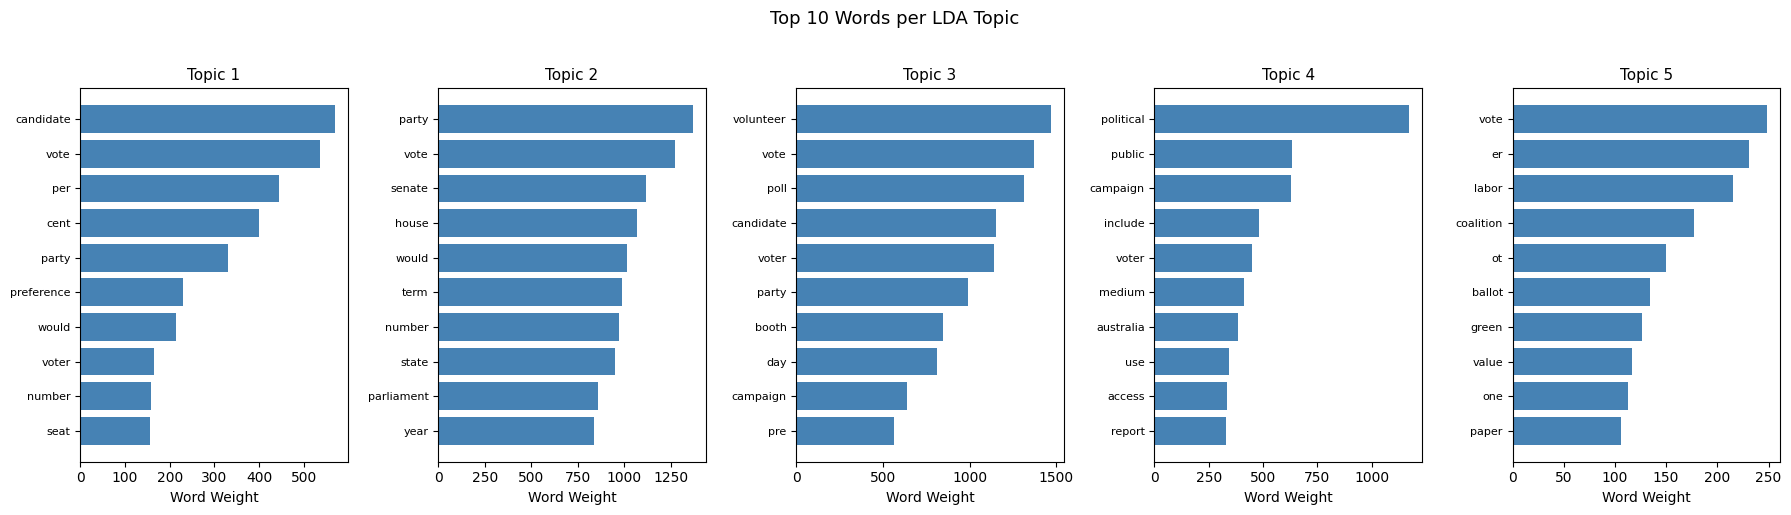

In [38]:
import matplotlib.pyplot as plt
import numpy as np

feature_names_lda = vectorizer.get_feature_names_out()
n_top_words = 10
n_topics = lda.n_components

topic_labels = [f"Topic {i+1}" for i in range(n_topics)]

fig, axes = plt.subplots(1, n_topics, figsize=(18, 5), sharey=False)

for topic_idx, (ax, topic) in enumerate(zip(axes, lda.components_)):
    top_indices = topic.argsort()[-n_top_words:][::-1]
    top_terms = [feature_names_lda[i] for i in top_indices]
    top_weights = [topic[i] for i in top_indices]

    ax.barh(top_terms[::-1], top_weights[::-1], color="steelblue")
    ax.set_title(f"Topic {topic_idx + 1}", fontsize=11)
    ax.set_xlabel("Word Weight")
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle("Top 10 Words per LDA Topic", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

*Step 12: Named Entity Recognition*
Named Entity Recognition identifies and classifies proper nouns organisations, people, locations, and dates mentioned in the submissions. 
This reveals *who* and *what* submitters are referring to.

In [39]:
import spacy, subprocess, sys
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# Download spacy model if not already present
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], 
                   capture_output=True)
    nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded")

sample_df = analysis_df.sample(min(100, len(analysis_df)), random_state=42)
entity_records = []

for _, row in sample_df.iterrows():
    doc = nlp(row["clean_text"][:5000])
    for ent in doc.ents:
        entity_records.append({
            "filename": row["filename"],
            "entity": ent.text.strip(),
            "label": ent.label_
        })

ner_df = pd.DataFrame(entity_records)
print(f"Total entities found: {len(ner_df)}")
print(ner_df["label"].value_counts())


spaCy model loaded
Total entities found: 1448
label
DATE        319
CARDINAL    234
ORG         234
GPE         201
NORP        169
ORDINAL     136
PERSON       79
TIME         40
QUANTITY     13
LOC          10
FAC           6
MONEY         4
PRODUCT       2
LANGUAGE      1
Name: count, dtype: int64


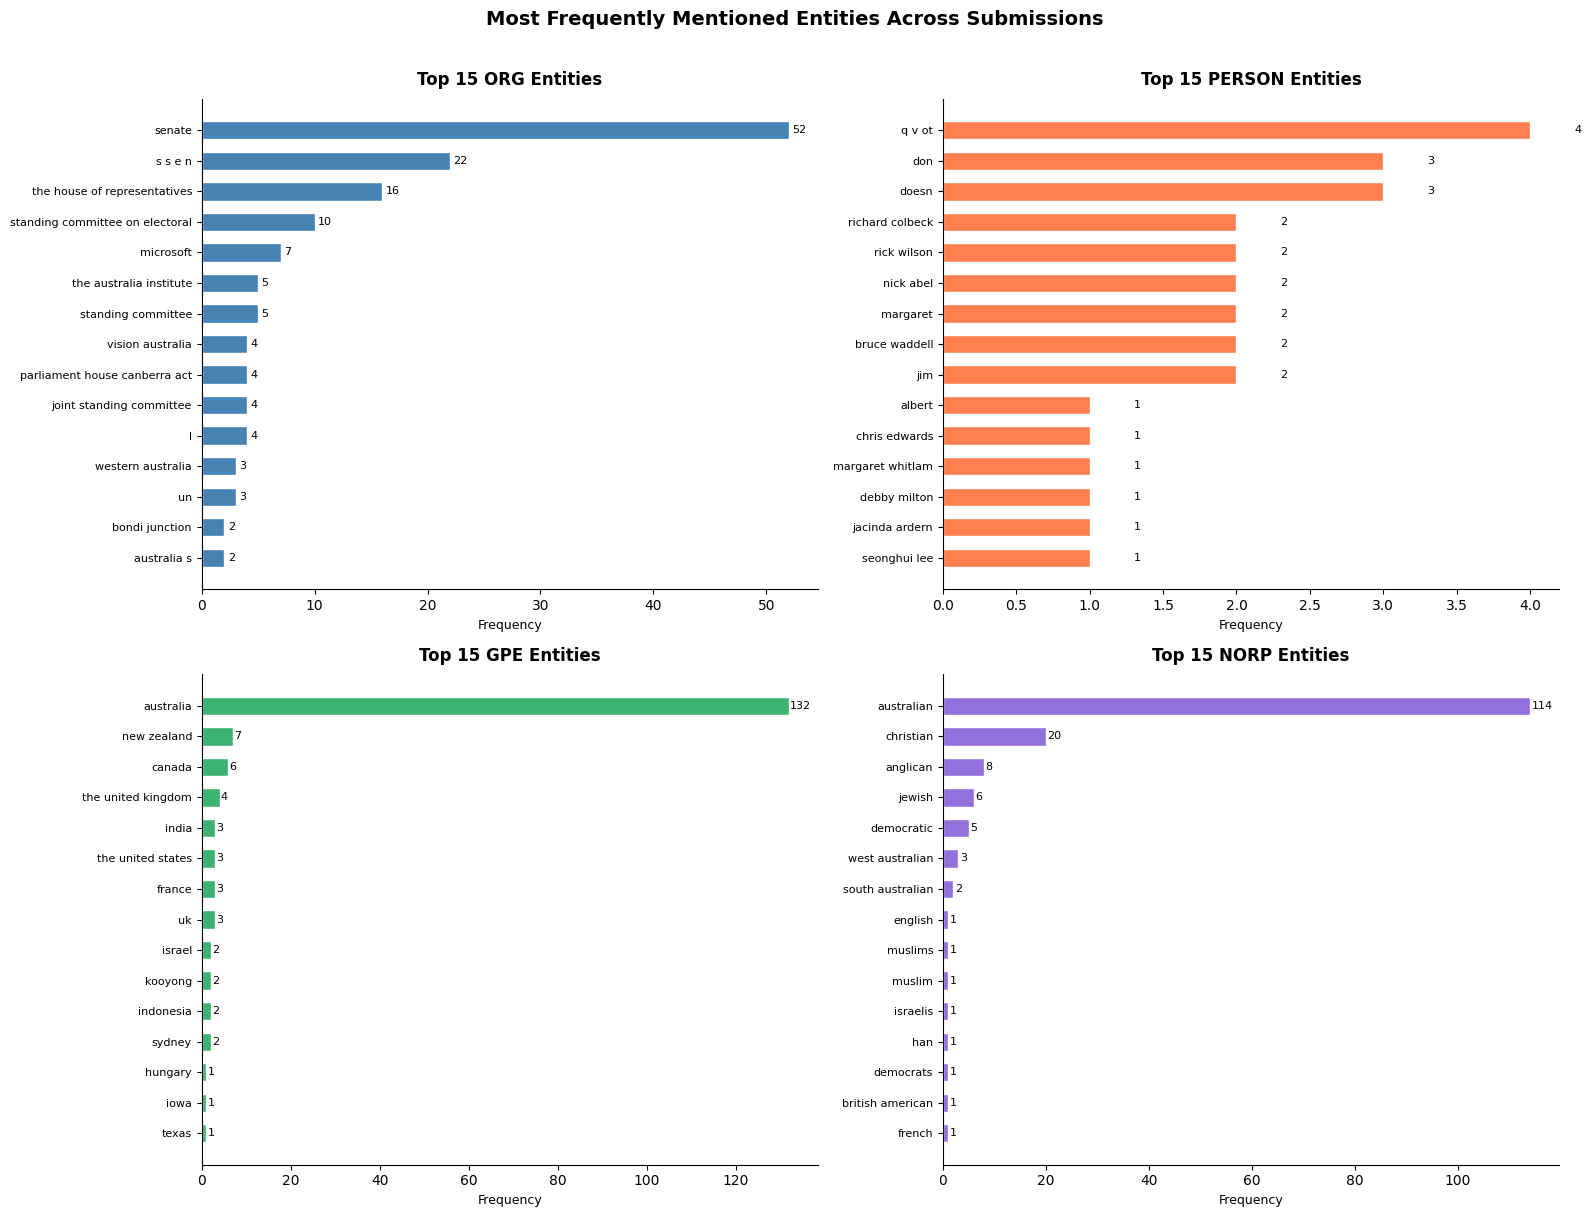

In [40]:
focus_labels = ["ORG", "PERSON", "GPE", "NORP"]  

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = {"ORG": "steelblue", "PERSON": "coral", "GPE": "mediumseagreen", "NORP": "mediumpurple"}

for ax, label in zip(axes.flatten(), focus_labels):
    subset = ner_df[ner_df["label"] == label]
    top = subset["entity"].value_counts().head(15)
    
    if top.empty:
        ax.set_title(f"{label} — no entities found")
        ax.axis("off")
        continue
    
    bars = ax.barh(top.index[::-1], top.values[::-1], 
                   color=colors[label], edgecolor="white", height=0.6)
    
    # Add value labels on each bar
    for bar, val in zip(bars, top.values[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=8)
    
    ax.set_title(f"Top 15 {label} Entities", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Frequency", fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Most Frequently Mentioned Entities Across Submissions", 
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

*Step 13: Sentiment Analysis*


In [41]:
from textblob import TextBlob
print("TextBlob ready")

TextBlob ready


Sentiment analysis quantifies the emotional tone of each submission using **TextBlob**, which assigns two scores **polarity** (−1 = very negative, +1 = very positive) and 
**subjectivity** (0 = purely objective, 1 = highly subjective). This allows us to assess whether submitters are broadly critical or supportive of the current electoral system, 
and whether sentiment differs across the LDA topics identified in the previous section.

Sentiment Summary:
       sentiment  subjectivity
count    274.000       274.000
mean       0.074         0.409
std        0.060         0.063
min       -0.139         0.208
25%        0.037         0.371
50%        0.075         0.412
75%        0.101         0.445
max        0.300         0.608


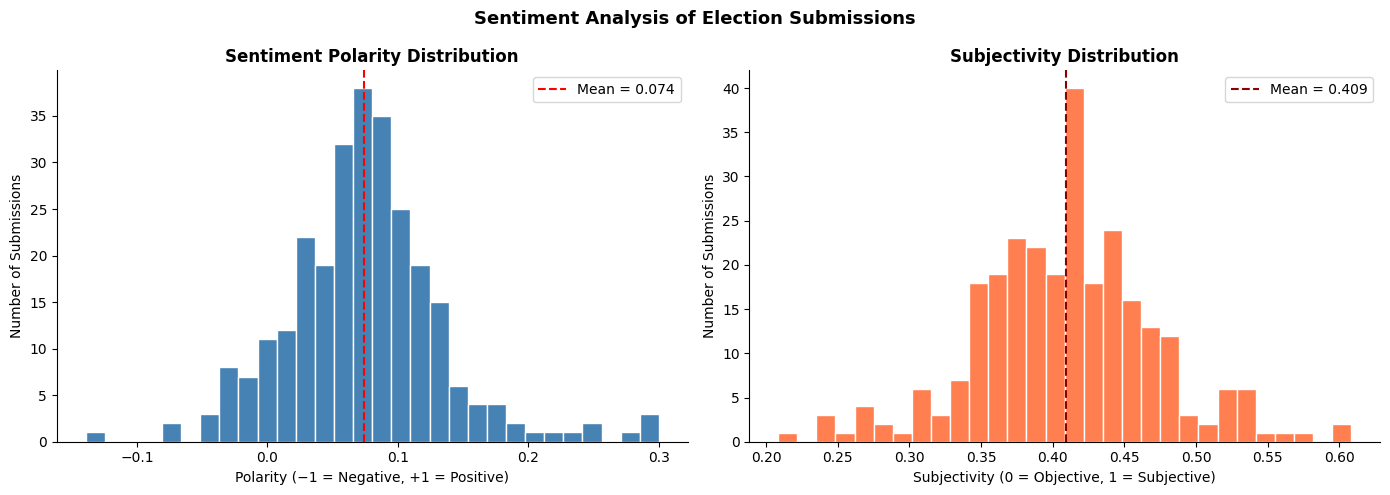


Mean Sentiment by LDA Topic:
                sentiment  subjectivity
dominant_topic                         
1                   0.088         0.405
2                   0.092         0.405
3                   0.069         0.422
4                   0.073         0.371
5                   0.067         0.418


In [42]:
from textblob import TextBlob
import matplotlib.pyplot as plt

# Compute polarity and subjectivity
analysis_df["sentiment"] = analysis_df["clean_text"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)
analysis_df["subjectivity"] = analysis_df["clean_text"].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

# Summary stats
print("Sentiment Summary:")
print(analysis_df[["sentiment", "subjectivity"]].describe().round(3))

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polarity distribution
axes[0].hist(analysis_df["sentiment"], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(analysis_df["sentiment"].mean(), color="red", linestyle="--",
                label=f"Mean = {analysis_df['sentiment'].mean():.3f}")
axes[0].set_title("Sentiment Polarity Distribution", fontweight="bold")
axes[0].set_xlabel("Polarity (−1 = Negative, +1 = Positive)")
axes[0].set_ylabel("Number of Submissions")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].legend()

# Subjectivity distribution
axes[1].hist(analysis_df["subjectivity"], bins=30, color="coral", edgecolor="white")
axes[1].axvline(analysis_df["subjectivity"].mean(), color="darkred", linestyle="--",
                label=f"Mean = {analysis_df['subjectivity'].mean():.3f}")
axes[1].set_title("Subjectivity Distribution", fontweight="bold")
axes[1].set_xlabel("Subjectivity (0 = Objective, 1 = Subjective)")
axes[1].set_ylabel("Number of Submissions")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].legend()

plt.suptitle("Sentiment Analysis of Election Submissions", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Sentiment by LDA topic
print("\nMean Sentiment by LDA Topic:")
print(analysis_df.groupby("dominant_topic")[["sentiment", "subjectivity"]].mean().round(3))

*Step 14: BERTopic Modelling*
BERTopic represents each submission as a semantic embedding using a sentence transformer model, then automatically clusters them into topics without requiring the number of topics to be set in advance producing more meaningful results than LDA on this data. It also reads the full context instead of just counting the number. 

In [43]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import numpy as np
import os

EMBED_CACHE = r"D:\NLP project\bertopic_embeddings.npy"

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

docs = analysis_df["processed_text"].tolist()

if os.path.exists(EMBED_CACHE):
    print("Loading cached embeddings...")
    embeddings = np.load(EMBED_CACHE)
else:
    print("Computing embeddings (first time only, will be cached)...")
    embeddings = embedding_model.encode(docs, show_progress_bar=True)
    np.save(EMBED_CACHE, embeddings)
    print(f"Embeddings saved to cache")

topic_model = BERTopic(
    language="english",
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=5
)

topics, probs = topic_model.fit_transform(docs, embeddings)

analysis_df["bertopic"] = topics

print(f"\nNumber of topics found: {topic_model.get_topic_info().shape[0] - 1}  (excl. outliers)")
print("\nTopic overview:")
print(topic_model.get_topic_info().head(10))


d:\NLP project\bertopic_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-09 23:17:49,293 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Loading cached embeddings...


2026-03-09 23:17:58,049 - BERTopic - Dimensionality - Completed ✓
2026-03-09 23:17:58,051 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 23:17:58,070 - BERTopic - Cluster - Completed ✓
2026-03-09 23:17:58,074 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-03-09 23:17:58,337 - BERTopic - Representation - Completed ✓



Number of topics found: 11  (excl. outliers)

Topic overview:
   Topic  Count                                   Name  \
0     -1    106   -1_election_electoral_candidate_vote   
1      0     39                  0_vote_ppvc_house_per   
2      1     28       1_volunteer_booth_poll_candidate   
3      2     17                    2_em_rep_booth_vote   
4      3     15  3_party_political_electoral_australia   
5      4     14             4_booth_volunteer_poll_pre   
6      5     13             5_volunteer_poll_pre_voter   
7      6     10     6_political_election_electoral_aec   
8      7     10              7_vote_system_senate_line   
9      8      9            8_people_vote_election_poll   

                                      Representation  \
0  [election, electoral, candidate, vote, aec, pa...   
1  [vote, ppvc, house, per, senate, election, sta...   
2  [volunteer, booth, poll, candidate, voter, ele...   
3  [em, rep, booth, vote, volunteer, date, pm, su...   
4  [party, politic

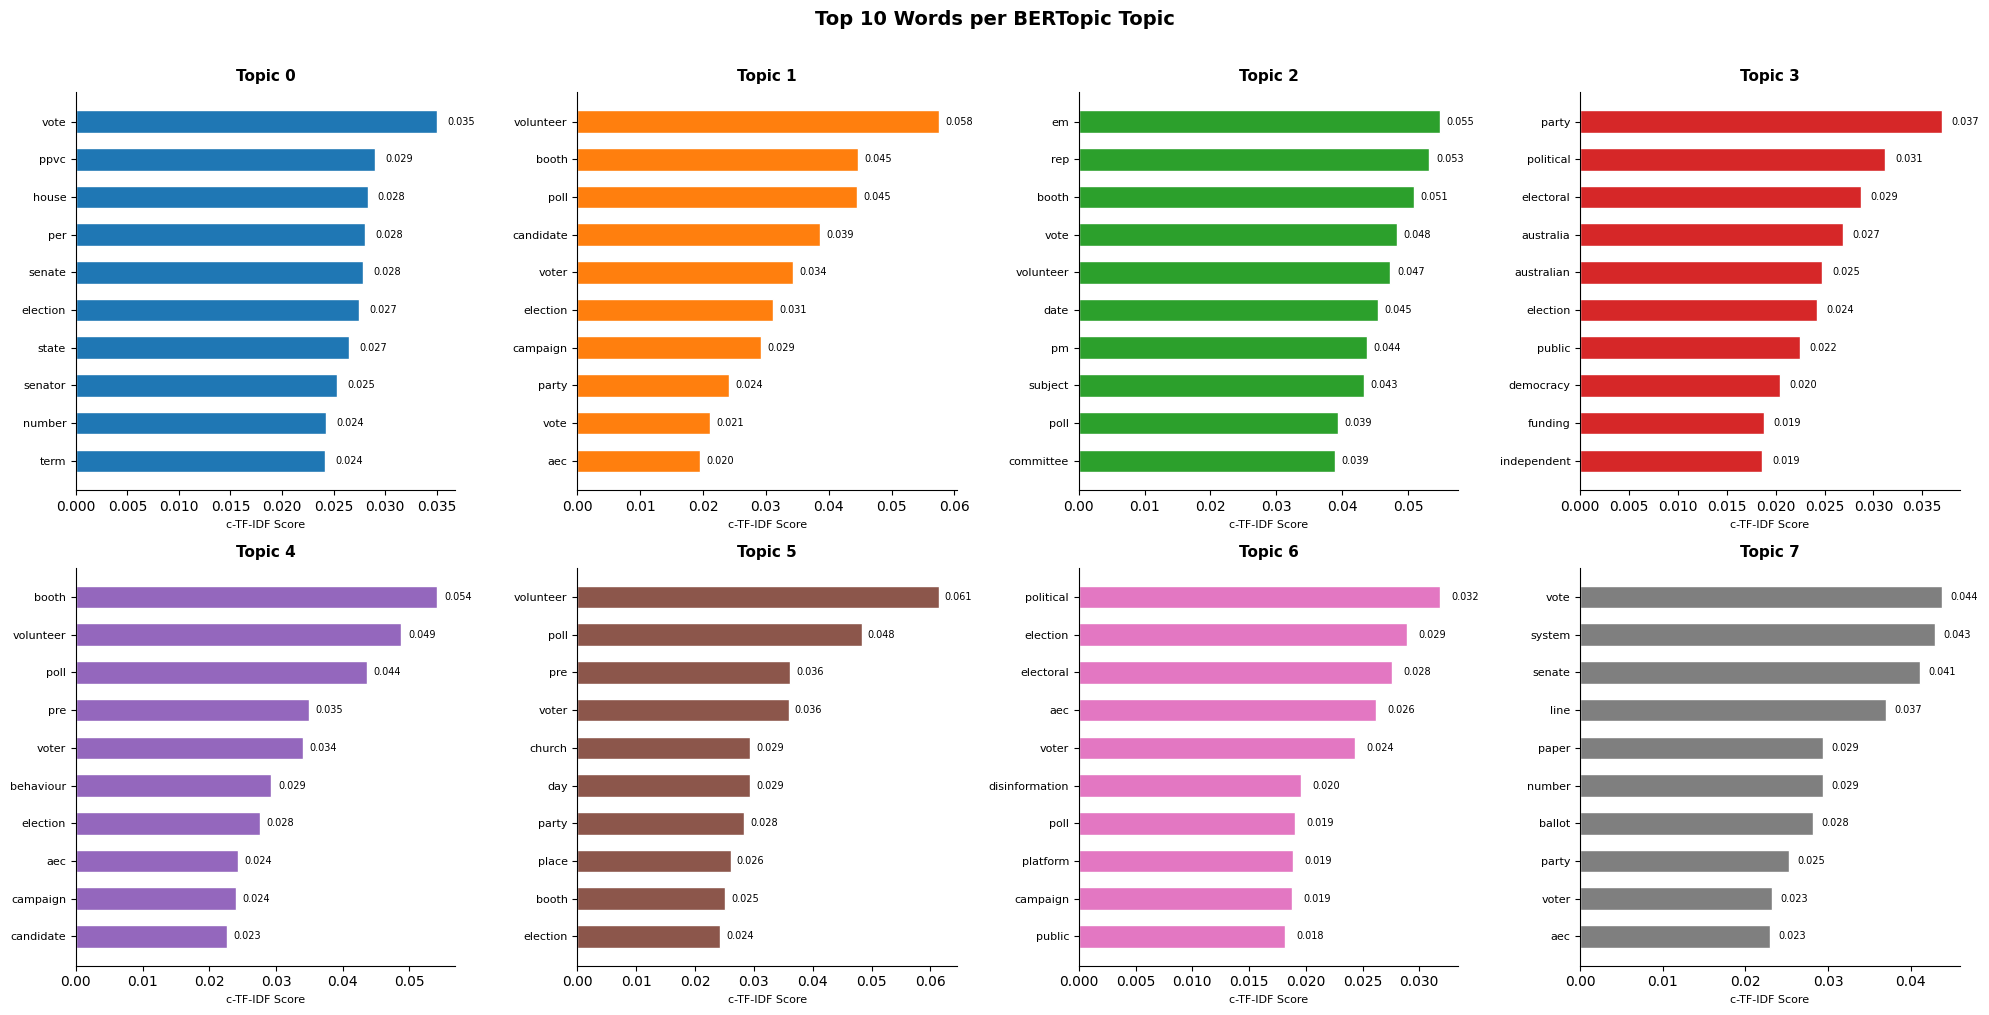


Top 10 Topics by Document Count:
bertopic
0    39
1    28
2    17
3    15
4    14
5    13
6    10
7    10
8     9
9     7
Name: count, dtype: int64


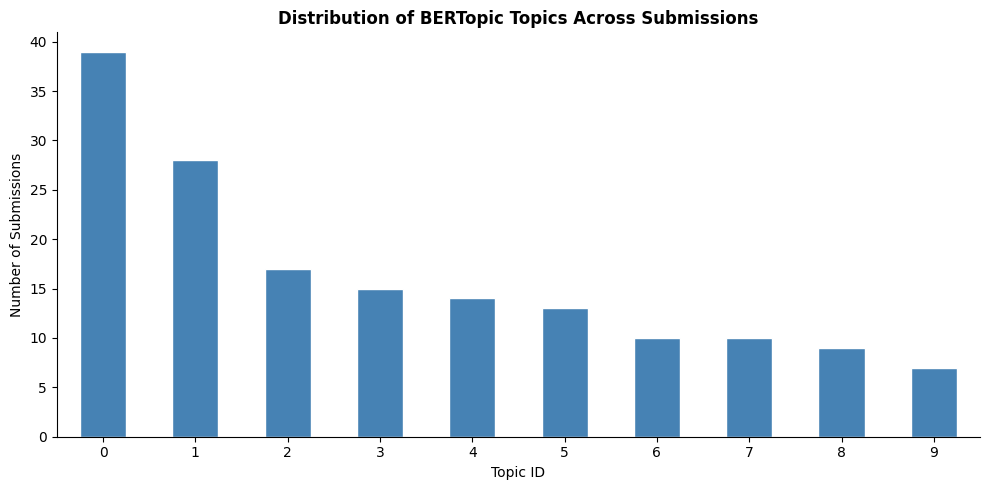

In [44]:
# Visualise top words per topic (top 8 topics)
import matplotlib.pyplot as plt

topic_info = topic_model.get_topic_info()
top_topics = topic_info[topic_info["Topic"] != -1]["Topic"].head(8).tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

colors = plt.cm.tab10.colors  # distinct colour per topic

for ax, topic_id, color in zip(axes.flatten(), top_topics, colors):
    words_weights = topic_model.get_topic(topic_id)
    if not words_weights:
        ax.axis("off")
        continue
    
    words = [w for w, _ in words_weights[:10]]
    weights = [s for _, s in words_weights[:10]]
    
    bars = ax.barh(words[::-1], weights[::-1], color=color, edgecolor="white", height=0.6)
    
    # Value labels on bars
    for bar, val in zip(bars, weights[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=7)
    
    ax.set_title(f"Topic {topic_id}", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("c-TF-IDF Score", fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Top 10 Words per BERTopic Topic", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Distribution of topics
print("\nTop 10 Topics by Document Count:")
topic_counts = analysis_df[analysis_df["bertopic"] != -1]["bertopic"].value_counts().head(10)
print(topic_counts)

# Bar chart of topic distribution
plt.figure(figsize=(10, 5))
topic_counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Distribution of BERTopic Topics Across Submissions", fontweight="bold")
plt.xlabel("Topic ID")
plt.ylabel("Number of Submissions")
plt.xticks(rotation=0)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()